In [3]:
import sys
sys.path.append('../functions')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from plotnine import *

# Linear regression

In [4]:
sim_result = pd.read_csv('../functions/sim_NN_results_no_penal10122022.csv')
sim_result.mean()

/tmp/ipykernel_903258/692507855.py:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.


contain                  0.994000
N                       50.000000
N_test                 500.000000
p                        2.000000
error_sd                 1.000000
level                    0.010087
use_true_contour         0.000000
contain_scb              0.862000
contain_CS_scb           0.998000
Lower_bound              0.950000
Upper_bound              0.985432
L1                       0.942288
L2                       0.858428
U1                       0.985476
U2                       0.997608
points_in_e1            60.218000
pre_mae                  0.494970
inner_points_num        50.540000
outer_points_num       451.650000
true_set_points_num    251.382000
dtype: float64

In [20]:
# Confidence set
sim_result = pd.read_csv('sim_results_13112022.csv')

In [21]:
sim_result = sim_result[sim_result.contain != -1]
sim_result = sim_result[sim_result.use_true_contour == 0]


In [23]:
sim_result[sim_result.p==159].groupby(['N', 'N_test', 'p', 'error_sd', 'level', 'use_true_contour']).mean()


contain  contain_scb  \
N      N_test p     error_sd level use_true_contour                         
50.0   500.0  159.0 1.0      0.2   0.0                 0.866        0.000   
                    2.0      0.2   0.0                 0.848        0.000   
                    4.0      0.2   0.0                 0.834        0.000   
150.0  500.0  159.0 1.0      0.2   0.0                 1.000        1.000   
                    2.0      0.2   0.0                 0.956        1.000   
                    4.0      0.2   0.0                 0.408        0.994   
250.0  500.0  159.0 1.0      0.2   0.0                 1.000        1.000   
                    2.0      0.2   0.0                 1.000        1.000   
                    4.0      0.2   0.0                 1.000        1.000   
500.0  500.0  159.0 1.0      0.2   0.0                 0.990        0.994   
                    2.0      0.2   0.0                 0.988        0.996   
                    4.0      0.2   0.0                 0.990        0.998   
1000.0 500.0  159.0 1.0      0.2   0.0                 0.948        0.950   
                    2.0      0.2   0.0                 0.978        0.954   
                    4.0      0.2   0.0                 0.970        0.958   

                                                     contain_CS_scb  \
N      N_test p     error_sd level use_true_contour                   
50.0   500.0  159.0 1.0      0.2   0.0                        0.990   
                    2.0      0.2   0.0                        0.982   
                    4.0      0.2   0.0                        0.984   
150.0  500.0  159.0 1.0      0.2   0.0                        1.000   
                    2.0      0.2   0.0                        1.000   
                    4.0      0.2   0.0                        1.000   
250.0  500.0  159.0 1.0      0.2   0.0                        1.000   
                    2.0      0.2   0.0                        1.000   
                    4.0      0.2   0.0                        1.000   
500.0  500.0  159.0 1.0      0.2   0.0                        1.000   
                    2.0      0.2   0.0                        1.000   
                    4.0      0.2   0.0                        1.000   
1000.0 500.0  159.0 1.0      0.2   0.0                        1.000   
                    2.0      0.2   0.0                        1.000   
                    4.0      0.2   0.0                        1.000   

                                                     Lower_bound  Upper_bound  \
N      N_test p     error_sd level use_true_contour                             
50.0   500.0  159.0 1.0      0.2   0.0                  0.950000     0.983892   
                    2.0      0.2   0.0                  0.950000     0.983872   
                    4.0      0.2   0.0                  0.950000     0.983636   
150.0  500.0  159.0 1.0      0.2   0.0                  0.950000     0.984016   
                    2.0      0.2   0.0                  0.949740     0.985412   
                    4.0      0.2   0.0                  0.949380     0.987552   
250.0  500.0  159.0 1.0      0.2   0.0                  0.935608     0.967612   
                    2.0      0.2   0.0                  0.934136     0.963632   
                    4.0      0.2   0.0                  0.933916     0.962180   
500.0  500.0  159.0 1.0      0.2   0.0                  0.950000     0.978352   
                    2.0      0.2   0.0                  0.950000     0.979876   
                    4.0      0.2   0.0                  0.950000     0.980340   
1000.0 500.0  159.0 1.0      0.2   0.0                  0.950000     0.976504   
                    2.0      0.2   0.0                  0.950000     0.978672   
                    4.0      0.2   0.0                  0.950000     0.979740   

                                                           L1        L2  \
N      N_test p     error_sd level use_true_contour                       
50.0   

In [50]:
df_plot = sim_result.groupby(['N', 'N_test', 'p', 'error_sd', 'level', 'use_true_contour']).mean().reset_index()
df_plot['group'] = 'Number of Covariates:'+df_plot["p"].astype(str)+'; '+ 'Noise SD: '+df_plot["error_sd"].astype(str)

In [51]:
df_plot = df_plot[df_plot.error_sd!=2]
df_plot = df_plot[np.logical_or(df_plot.p == 9,df_plot.p == 159)]

In [52]:
df_plot["p"] = df_plot["p"].astype("category")
df_plot["error_sd"] = df_plot["error_sd"].astype("category")

In [142]:
df_plot

,N,N_test,p,error_sd,level,use_true_contour,contain,contain_scb,contain_CS_scb,Lower_bound,...,L1,L2,U1,U2,points_in_e1,pre_mae,inner_points_num,outer_points_num,true_set_points_num,group
0,50.0,500.0,9.0,1.0,0.2,0.0,0.978,0.946,0.998,0.950000,...,0.899196,0.949764,0.982024,0.996480,12.098,0.395076,140.518,337.900,236.478,Number of Covariates:9.0; Noise SD: 1.0
2,50.0,500.0,9.0,4.0,0.2,0.0,0.986,0.966,0.998,0.950000,...,0.938064,0.943056,0.982900,0.998520,35.902,1.552051,12.216,482.496,236.734,Number of Covariates:9.0; Noise SD: 4.0
9,50.0,500.0,159.0,1.0,0.2,0.0,0.866,0.000,0.990,0.950000,...,0.828216,0.950000,0.983892,0.999316,46.460,8.440065,1.814,497.348,245.804,Number of Covariates:159.0; Noise SD: 1.0
11,50.0,500.0,159.0,4.0,0.2,0.0,0.834,0.000,0.984,0.950000,...,0.820128,0.950000,0.983636,0.999356,46.204,8.676118,1.718,497.488,245.702,Number of Covariates:159.0; Noise SD: 4.0
18,150.0,500.0,9.0,1.0,0.2,0.0,0.970,0.924,0.998,0.950000,...,0.796696,0.950000,0.979568,0.992436,4.916,0.207505,191.364,278.196,234.074,Number of Covariates:9.0; Noise SD: 1.0
20,150.0,500.0,9.0,4.0,0.2,0.0,0.936,0.886,0.992,0.950000,...,0.889012,0.949984,0.981648,0.997428,15.930,0.839924,79.204,407.992,240.820,Number of Covariates:9.0; Noise SD: 4.0
27,150.0,500.0,159.0,1.0,0.2,0.0,1.000,1.000,1.000,0.950000,...,0.504548,0.950000,0.984016,0.999372,33.764,4.056098,5.384,494.536,247.982,Number of Covariates:159.0; Noise SD: 1.0
29,150.0,500.0,159.0,4.0,0.2,0.0,0.408,0.994,1.000,0.949380,...,0.016624,0.949380,0.987552,0.999600,30.398,13.161498,14.128,485.428,247.732,Number of Covariates:159.0; Noise SD: 4.0
36,250.0,500.0,9.0,1.0,0.2,0.0,0.960,0.930,1.000,0.950000,...,0.759332,0.950000,0.978528,0.990816,3.970,0.159126,205.446,271.656,237.910,Number of Covariates:9.0; Noise SD: 1.0
38,250.0,500.0,9.0,4.0,0.2,0.0,0.962,0.916,0.994,0.950000,...,0.868556,0.950000,0.981124,0.996868,11.986,0.633202,104.586,370.704,233.956,Number of Covariates:9.0; Noise SD: 4.0


In [145]:
table_temp = df_plot[np.logical_and(df_plot.error_sd == 1, df_plot.p == 9)].pivot(index = ['N'], columns = [], 
                           values = ['inner_points_num', 'outer_points_num', 'points_in_e1', 'Lower_bound', 'contain','Upper_bound'])

In [149]:
table_temp = table_temp.round(3)
table_temp

,inner_points_num,outer_points_num,points_in_e1,Lower_bound,contain,Upper_bound
N,,,,,,
50.0,140.518,337.900,12.098,0.95,0.978,0.982
150.0,191.364,278.196,4.916,0.95,0.970,0.980
250.0,205.446,271.656,3.970,0.95,0.960,0.978
500.0,213.714,255.820,2.868,0.95,0.940,0.977
1000.0,223.918,252.464,2.256,0.95,0.958,0.975


In [150]:
print(table_temp.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
       &  inner\_points\_num &  outer\_points\_num &  points\_in\_e1 &  Lower\_bound &  contain &  Upper\_bound \\
N &                   &                   &               &              &          &              \\
\midrule
50.0   &           140.518 &           337.900 &        12.098 &         0.95 &    0.978 &        0.982 \\
150.0  &           191.364 &           278.196 &         4.916 &         0.95 &    0.970 &        0.980 \\
250.0  &           205.446 &           271.656 &         3.970 &         0.95 &    0.960 &        0.978 \\
500.0  &           213.714 &           255.820 &         2.868 &         0.95 &    0.940 &        0.977 \\
1000.0 &           223.918 &           252.464 &         2.256 &         0.95 &    0.958 &        0.975 \\
\bottomrule
\end{tabular}



/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: results/coverage_plot_linear.png


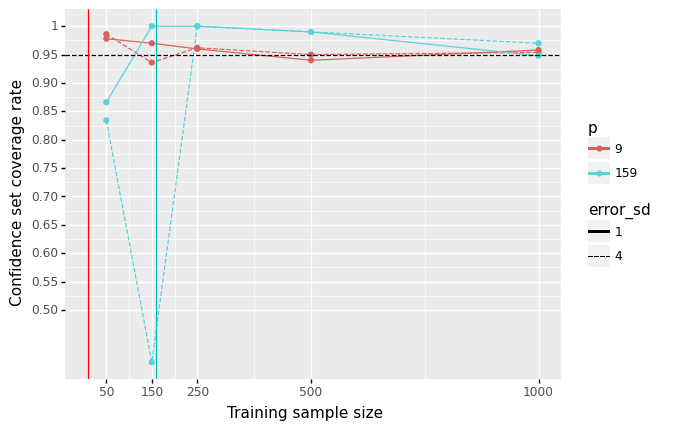

In [141]:
coverage_plot = (ggplot(df_plot)+
 geom_line(aes(x = 'N', y = 'contain', color = 'p', linetype = 'error_sd'))+
 geom_point(aes(x = 'N', y = 'contain', color = 'p'))+
 #geom_ribbon(aes(x = 'N',ymin='Lower_bound', ymax='Upper_bound',fill = 'p'), alpha=0.1)+
 #ylim(0.5, 1)+
 geom_hline(yintercept = 0.95,  linetype="dashed", color = "black")+
 geom_vline(xintercept = 159,  color="#00BFC4", linetype = 'solid')+
 geom_vline(xintercept = 9,  color="red", linetype = 'solid')+
 scale_x_continuous(breaks=np.array(df_plot.N[~df_plot.N.duplicated()]))+
 scale_y_continuous(breaks=[0, 0.5, 0.55, 0.6,0.65, 0.7,0.75,0.8,0.85, 0.9,0.95, 1])+
 ylab('Confidence set coverage rate')+
 xlab('Training Sample size')
)
coverage_plot.save('results/coverage_plot_linear.png',dpi = 300)
coverage_plot.draw()

Simulation variance horizontal line.
Where sample size equal to p.

# Neural network

In [36]:
sim_result = pd.read_csv('sim_NN_results_23112022.csv')


In [37]:
sim_result.columns


Index(['0', 'contain', 'N', 'N_test', 'p', 'error_sd', 'level',
       'use_true_contour', 'contain_scb', 'contain_CS_scb', 'Lower_bound',
       'Upper_bound', 'L1', 'L2', 'U1', 'U2', 'points_in_e1', 'pre_mae',
       'inner_points_num', 'outer_points_num', 'true_set_points_num'],
      dtype='object')

In [39]:
print(sim_result[['contain', 'N', 'p', 'contain_scb', 'inner_points_num', 'outer_points_num', 'points_in_e1']].groupby(['N', 'p']).mean().to_latex())

\begin{tabular}{llrrrrr}
\toprule
      &     &  contain &  contain\_scb &  inner\_points\_num &  outer\_points\_num &  points\_in\_e1 \\
N & p &          &              &                   &                   &               \\
\midrule
50.0  & 2.0 &    0.924 &        0.484 &            81.676 &           423.758 &        42.892 \\
      & 4.0 &    0.948 &        0.594 &            30.964 &           465.798 &        61.254 \\
100.0 & 2.0 &    0.944 &        0.458 &           121.498 &           375.128 &        27.352 \\
      & 4.0 &    0.966 &        0.628 &            65.668 &           434.600 &        36.830 \\
200.0 & 2.0 &    0.892 &        0.370 &           158.314 &           345.722 &        20.384 \\
      & 4.0 &    0.938 &        0.498 &           104.660 &           396.230 &        26.162 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_89/3349944937.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


# Interpretation of black box algorithms

In [33]:
sim_inter_result = pd.read_csv('sim_results_interpretation25112022.csv')


In [45]:
temp_table = sim_inter_result.loc[sim_inter_result.N!=50, ['N', 'p', 'N_test','contain', 'all_causal', 'percent_causal_selected']].groupby(['N', 'p', 'N_test']).mean()


In [46]:
print(temp_table.to_latex())# This for p_casual=20

\begin{tabular}{lllrrr}
\toprule
      &      &        &  contain &  all\_causal &  percent\_causal\_selected \\
N & p & N\_test &          &             &                          \\
\midrule
100.0 & 50.0 & 200.0  &    1.000 &       1.000 &                   0.0122 \\
      &      & 500.0  &    1.000 &       1.000 &                   0.0602 \\
      &      & 1000.0 &    1.000 &       0.998 &                   0.1171 \\
200.0 & 50.0 & 200.0  &    0.984 &       1.000 &                   0.1073 \\
      &      & 500.0  &    0.984 &       1.000 &                   0.2935 \\
      &      & 1000.0 &    0.976 &       0.992 &                   0.4238 \\
\bottomrule
\end{tabular}



In [27]:
df_plot = sim_inter_result.groupby(['N', 'p', 'p_causal']).mean().reset_index()
df_plot["p"] = df_plot["p"].astype("category")
df_plot = df_plot[df_plot.p==50]

In [28]:
df_plot

,N,p,p_causal,contain,all_causal,percent_causal_selected,N_test,error_sd,level,L
0,200.0,50.0,10.0,0.978,0.990,0.4312,500.0,1.0,0.0,0.95
1,200.0,50.0,20.0,0.988,1.000,0.3090,500.0,1.0,0.0,0.95
4,400.0,50.0,10.0,0.944,0.998,0.4704,500.0,1.0,0.0,0.95
5,400.0,50.0,20.0,0.962,1.000,0.3031,500.0,1.0,0.0,0.95


In [29]:
df_plot = pd.melt(df_plot, id_vars=['N', 'p', 'p_causal'], value_vars= ['all_causal', 'percent_causal_selected'], var_name= 'Type', value_name='Percentage')
df_plot["p_causal"] = df_plot["p_causal"].astype("category")

In [30]:
df_plot

,N,p,p_causal,Type,Percentage
0,200.0,50.0,10.0,all_causal,0.9900
1,200.0,50.0,20.0,all_causal,1.0000
2,400.0,50.0,10.0,all_causal,0.9980
3,400.0,50.0,20.0,all_causal,1.0000
4,200.0,50.0,10.0,percent_causal_selected,0.4312
5,200.0,50.0,20.0,percent_causal_selected,0.3090
6,400.0,50.0,10.0,percent_causal_selected,0.4704
7,400.0,50.0,20.0,percent_causal_selected,0.3031


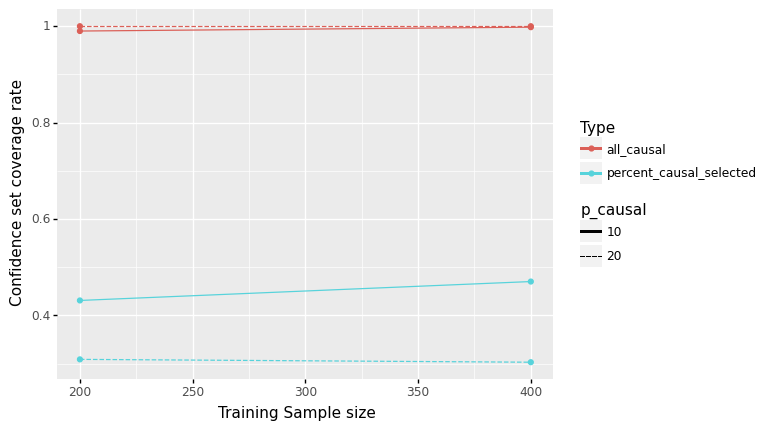

In [32]:
coverage_plot = (ggplot(df_plot)+
 geom_line(aes(x = 'N', y = 'Percentage', color = 'Type', linetype = 'p_causal'))+
 geom_point(aes(x = 'N', y = 'Percentage', color = 'Type'))+
 #geom_ribbon(aes(x = 'N',ymin='Lower_bound', ymax='Upper_bound',fill = 'p'), alpha=0.1)+
 #ylim(0.5, 1)+
 # scale_x_continuous(breaks=np.array(df_plot.N[~df_plot.N.duplicated()]))+
 # scale_y_continuous(breaks=[0, 0.5, 0.55, 0.6,0.65, 0.7,0.75,0.8,0.85, 0.9,0.95, 1])+
 ylab('Confidence set coverage rate')+
 xlab('Training Sample size')
)
#coverage_plot.save('results/coverage_plot_linear.png',dpi = 300)
coverage_plot.draw()